<a href="https://colab.research.google.com/github/sadizaman11-Bangla/Performance-Comparison-of-Decision-Tree-and-Random-Forest-of-mud-density-and-viscosity/blob/main/Group_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Shape: (500, 21)

First 5 Rows:
   Sample_ID  Water_ml  Bentonite_g  Barite_g  PAC_g  Xanthan_g  NaCl_g  \
0          1       340         33.2      27.6   0.19       1.64     1.7   
1          2       360         27.3       4.3   2.34       0.10     4.0   
2          3       355         29.4      39.5   2.48       0.99     9.6   
3          4       348         22.6      68.6   0.47       0.84    13.6   
4          5       371         25.3      58.8   3.78       0.95    12.0   

   NaOH_ml  Temperature_C  Mixing_Time_min  ...  Theta600  Theta300  \
0      5.1           75.0               16  ...      67.2      42.7   
1      4.9           32.3               23  ...      63.5      40.9   
2      6.4           50.6               24  ...      70.8      45.8   
3      2.1           51.9               11  ...      44.7      28.6   
4      1.4           63.6               24  ...      70.7      46.6   

   Plastic_Viscosity_cp  Apparent_Viscosity_cp  Yield_Point_lb_100ft2  \
0           

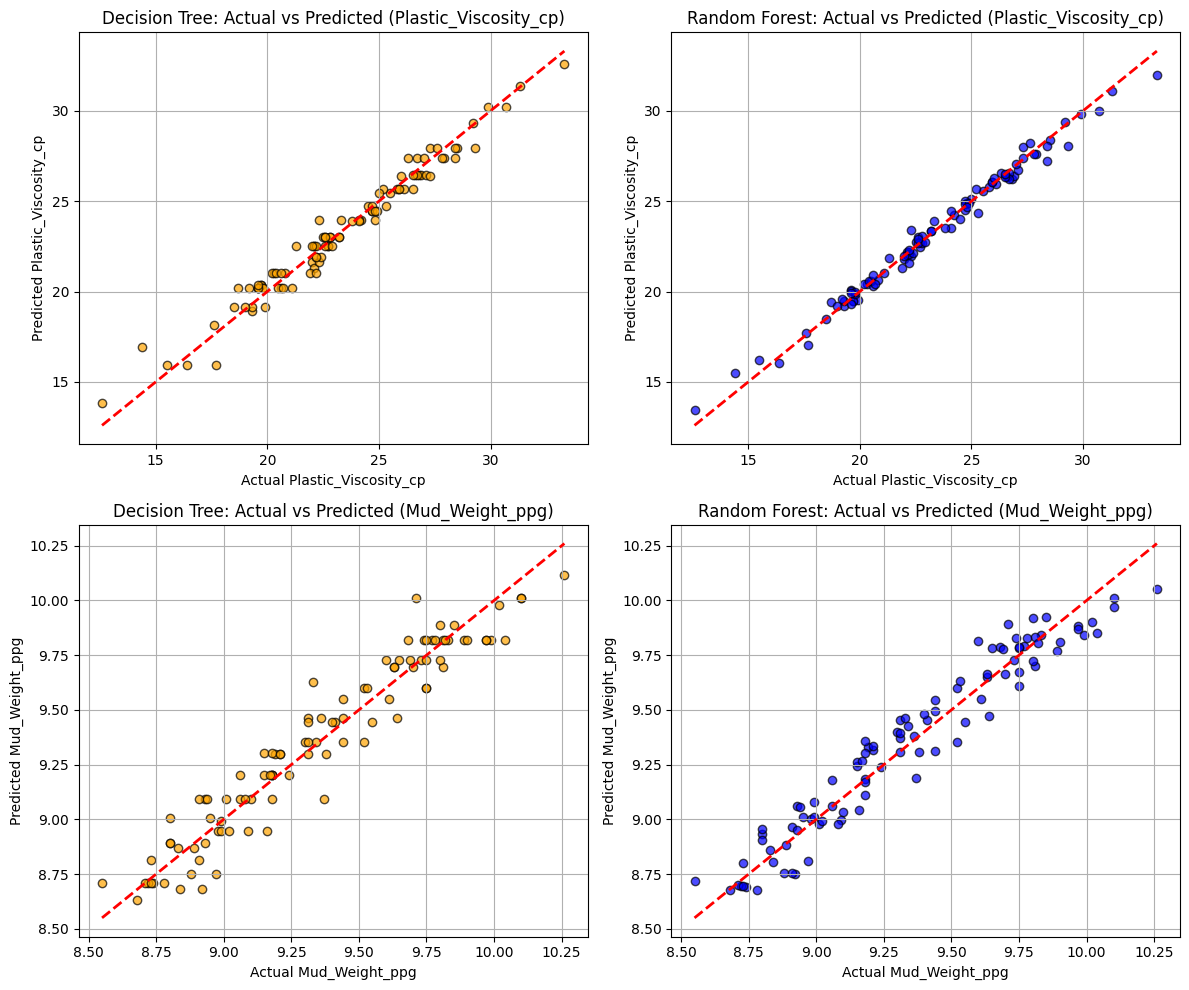

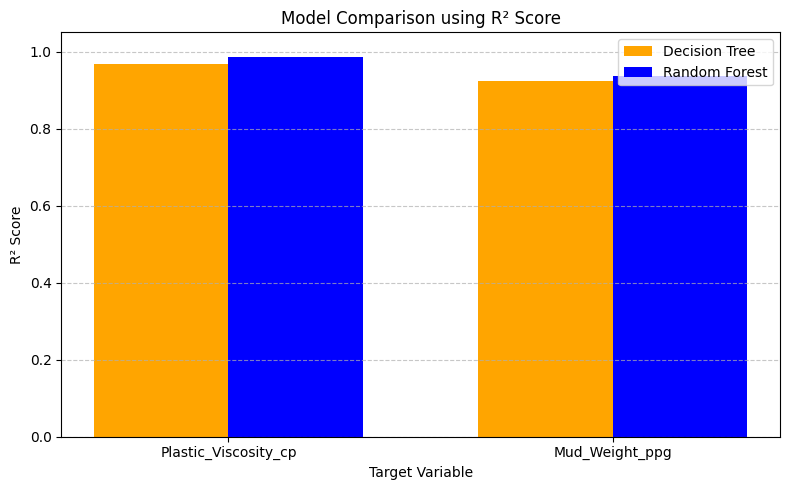

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score

# ==========================================
# 1. DATA LOADING & EXPLORATION
# ==========================================
file_path = "/content/Drilling_fluid_dataset (1).csv"
df = pd.read_csv(file_path)

print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# ==========================================
# 2. DATA CLEANING
# ==========================================
# Replace infinite values and handle missing numeric data with mean
df = df.replace([np.inf, -np.inf], np.nan)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Check and drop duplicate rows
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

# Dynamic target detection for Plastic Viscosity and Mud Weight
pv_col = [c for c in df.columns if 'plastic' in c.lower() or 'pv' in c.lower()][0]
mw_col = [c for c in df.columns if ('mud' in c.lower() and 'weight' in c.lower()) or 'mw' in c.lower()][0]

exclude_cols = [pv_col, mw_col]
if 'Sample_ID' in df.columns:
    exclude_cols.append('Sample_ID')
if 'Sample' in df.columns:
    exclude_cols.append('Sample')

# Features (X) and Target (y) separation
X = df.drop(columns=exclude_cols).select_dtypes(include=[np.number])
y = df[[pv_col, mw_col]]

# ==========================================
# 3. SPLITTING DATA
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ==========================================
# 4. TUNING MODELS (5-Fold GridSearchCV)
# ==========================================
# A. Decision Tree Hyperparameter Tuning
dt_param_grid = {
    'estimator__max_depth': [3, 5, 10, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

dt_base = MultiOutputRegressor(DecisionTreeRegressor(random_state=42))
dt_grid = GridSearchCV(estimator=dt_base, param_grid=dt_param_grid, cv=5, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt_model = dt_grid.best_estimator_

# B. Random Forest Hyperparameter Tuning
rf_param_grid = {
    'estimator__n_estimators': [50, 100, 200],
    'estimator__max_depth': [5, 10, None],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2]
}

rf_base = MultiOutputRegressor(RandomForestRegressor(random_state=42))
rf_grid = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_

# ==========================================
# 5. PREDICTION (On Unseen Test Data)
# ==========================================
y_pred_dt = best_dt_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

y_pred_dt_df = pd.DataFrame(y_pred_dt, columns=y.columns, index=y_test.index)
y_pred_rf_df = pd.DataFrame(y_pred_rf, columns=y.columns, index=y_test.index)

# ==========================================
# 6. EVALUATION (R^2)
# ==========================================
def compute_metrics(y_true, y_pred):
    metrics = {}
    for col in y_true.columns:
        r2 = r2_score(y_true[col], y_pred[col])
        metrics[col] = { 'R2': r2}
    return metrics

dt_metrics = compute_metrics(y_test, y_pred_dt_df)
rf_metrics = compute_metrics(y_test, y_pred_rf_df)

metrics_summary = []
for target in y.columns:
    metrics_summary.append({
        'Target': target,
        'Model': 'Decision Tree',
        'R2': dt_metrics[target]['R2'],
    })
    metrics_summary.append({
        'Target': target,
        'Model': 'Random Forest',
        'R2': rf_metrics[target]['R2'],

    })

summary_df = pd.DataFrame(metrics_summary)
print("\n=== MODEL EVALUATION METRICS ===")
print(summary_df.to_string(index=False))

# ==========================================
# 7. VISUALIZATIONS
# ==========================================
# 1. Actual vs Predicted Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Decision Tree - Plastic Viscosity
axes[0, 0].scatter(y_test[pv_col], y_pred_dt_df[pv_col], color='orange', alpha=0.7, edgecolors='black')
axes[0, 0].plot([y_test[pv_col].min(), y_test[pv_col].max()], [y_test[pv_col].min(), y_test[pv_col].max()], 'r--', lw=2)
axes[0, 0].set_title(f"Decision Tree: Actual vs Predicted ({pv_col})")
axes[0, 0].set_xlabel(f"Actual {pv_col}")
axes[0, 0].set_ylabel(f"Predicted {pv_col}")
axes[0, 0].grid(True)

# Random Forest - Plastic Viscosity
axes[0, 1].scatter(y_test[pv_col], y_pred_rf_df[pv_col], color='blue', alpha=0.7, edgecolors='black')
axes[0, 1].plot([y_test[pv_col].min(), y_test[pv_col].max()], [y_test[pv_col].min(), y_test[pv_col].max()], 'r--', lw=2)
axes[0, 1].set_title(f"Random Forest: Actual vs Predicted ({pv_col})")
axes[0, 1].set_xlabel(f"Actual {pv_col}")
axes[0, 1].set_ylabel(f"Predicted {pv_col}")
axes[0, 1].grid(True)

# Decision Tree - Mud Weight
axes[1, 0].scatter(y_test[mw_col], y_pred_dt_df[mw_col], color='orange', alpha=0.7, edgecolors='black')
axes[1, 0].plot([y_test[mw_col].min(), y_test[mw_col].max()], [y_test[mw_col].min(), y_test[mw_col].max()], 'r--', lw=2)
axes[1, 0].set_title(f"Decision Tree: Actual vs Predicted ({mw_col})")
axes[1, 0].set_xlabel(f"Actual {mw_col}")
axes[1, 0].set_ylabel(f"Predicted {mw_col}")
axes[1, 0].grid(True)

# Random Forest - Mud Weight
axes[1, 1].scatter(y_test[mw_col], y_pred_rf_df[mw_col], color='blue', alpha=0.7, edgecolors='black')
axes[1, 1].plot([y_test[mw_col].min(), y_test[mw_col].max()], [y_test[mw_col].min(), y_test[mw_col].max()], 'r--', lw=2)
axes[1, 1].set_title(f"Random Forest: Actual vs Predicted ({mw_col})")
axes[1, 1].set_xlabel(f"Actual {mw_col}")
axes[1, 1].set_ylabel(f"Predicted {mw_col}")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# 2. Model Comparison Bar Chart (R^2 Score)
plt.figure(figsize=(8, 5))
targets = summary_df['Target'].unique()
x_indexes = np.arange(len(targets))
width = 0.35

dt_r2 = summary_df[summary_df['Model'] == 'Decision Tree']['R2'].values
rf_r2 = summary_df[summary_df['Model'] == 'Random Forest']['R2'].values

plt.bar(x_indexes - width/2, dt_r2, width=width, label='Decision Tree', color='orange')
plt.bar(x_indexes + width/2, rf_r2, width=width, label='Random Forest', color='blue')

plt.xlabel("Target Variable")
plt.ylabel("R² Score")
plt.title("Model Comparison using R² Score")
plt.xticks(ticks=x_indexes, labels=targets)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()